### Instalasi Library

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
import warnings
from pathlib import Path
import joblib
import json
warnings.filterwarnings("ignore")

## **LOAD DATA DAN PENGECEKAN DATA**

### load data

In [83]:
DATA_PATH = "diabetes_frankurt_germany_1.xlsx"
data = pd.read_excel(DATA_PATH)
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138.0,62.0,35,0.0,33.6,0.127,47,1
1,0,84.0,82.0,31,125.0,38.2,0.233,23,0
2,0,145.0,72.0,29,126.0,44.2,0.630,31,1
3,0,135.0,68.0,42,250.0,42.3,0.365,24,1
4,1,139.0,62.0,41,480.0,40.7,0.536,21,0
...,...,...,...,...,...,...,...,...,...
1995,2,75.0,64.0,24,54.9,29.7,0.400,33,0
1996,8,179.0,72.0,42,130.0,32.7,0.700,36,1
1997,6,84.9,78.0,29,126.0,31.2,0.400,42,0
1998,0,129.0,110.0,46,130.0,67.1,0.300,26,1


### pengecekan data duplikat

In [84]:
# jumlah duplikat (yang dihitung duplikatnya = baris setelah kemunculan pertama)
jumlah_duplikat = data.duplicated().sum()
print(f"Jumlah data duplikat: {jumlah_duplikat}")

# ambil SEMUA baris yang terlibat duplikat (termasuk baris pertama + kembarannya)
df_duplikat = data[data.duplicated(keep=False)].copy()

# No = index asli (tanpa reset_index)
df_duplikat.insert(0, "No", df_duplikat.index)

df_duplikat

Jumlah data duplikat: 8


,No,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
494,494,3,80.0,72.0,29,126.0,32.4,0.2,22,0
495,495,6,166.0,74.0,0,0.0,26.6,0.3,66,0
868,868,3,82.0,70.0,29,126.0,21.1,0.4,25,0
958,958,4,99.0,72.0,17,126.0,25.6,0.3,28,0
961,961,2,89.0,90.0,30,0.0,33.5,0.3,42,0
1213,1213,7,137.0,90.0,41,126.0,32.0,0.4,39,0
1218,1218,9,170.0,74.0,31,0.0,44.0,0.4,43,1
1462,1462,9,71.9,78.0,25,126.0,31.6,0.3,38,0
1547,1547,4,99.0,72.0,17,126.0,25.6,0.3,28,0
1550,1550,2,89.0,90.0,30,0.0,33.5,0.3,42,0


In [85]:
# Cek missing values dan nilai 0 dan data duplikasi
print("\nNilai 0 pada setiap kolom:")
jumlah_nol = {}
for kolom in data.columns:
    if kolom != 'Outcome':
        hitung_nol = (data[kolom] == 0).sum()
        jumlah_nol[kolom] = hitung_nol
        print(f"{kolom}: {hitung_nol}")

# Total baris yang memiliki minimal satu nilai 0 (selain Outcome dan Pregnancies)
fitur_dengan_nol = data.drop(['Outcome', 'Pregnancies'], axis=1) == 0
total_baris_nol = fitur_dengan_nol.any(axis=1).sum()
persentase_baris_nol = (total_baris_nol / len(data)) * 100
print(f"Total baris yang memiliki minimal satu nilai 0: {total_baris_nol}")
print(f"Persentase baris dengan nilai 0: {persentase_baris_nol:.2f}%")


Nilai 0 pada setiap kolom:
Pregnancies: 301
Glucose: 4
BloodPressure: 32
SkinThickness: 176
Insulin: 316
BMI: 13
DiabetesPedigreeFunction: 0
Age: 0
Total baris yang memiliki minimal satu nilai 0: 320
Persentase baris dengan nilai 0: 16.00%


## **PREPOCESSING**

### Hapus data duplikat

In [45]:
if jumlah_duplikat > 0:
    data = data.drop_duplicates().reset_index(drop=True)
    print(f"Jumlah data duplikat setelah penghapusan: {data.duplicated().sum()}")

Jumlah data duplikat setelah penghapusan: 0


### Imputasi dengan KNNImputer

In [46]:
data_temp = data.copy()
kolom_hilang = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
if persentase_baris_nol > 10:
    # 0 dianggap missing untuk kolom di atas
    data_temp[kolom_hilang] = data_temp[kolom_hilang].replace(0, np.nan)
    X_untuk_imputasi = data_temp.drop(columns=["Outcome"])
    y = data_temp["Outcome"]
    imputer_knn = KNNImputer(n_neighbors=5)
    X_terimputasi = imputer_knn.fit_transform(X_untuk_imputasi)
    data = pd.DataFrame(X_terimputasi, columns=X_untuk_imputasi.columns)
    data["Outcome"] = y.to_numpy()

    print(f"Jumlah missing values setelah imputasi:\n{data.isnull().sum()}")
else:
    data = data_temp.dropna(subset=kolom_hilang).reset_index(drop=True)
    print(f"Jumlah data setelah menghapus baris dengan nilai 0: {len(data)}")

Jumlah missing values setelah imputasi:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### Normalisasi dengan MinMaxScaler

In [47]:
X = data.drop(columns=["Outcome"])
y = data["Outcome"]
min_max = MinMaxScaler()
X_ternormalisasi = min_max.fit_transform(X)
X_ternormalisasi = pd.DataFrame(X_ternormalisasi, columns=X.columns)
X_ternormalisasi

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.117647,0.606061,0.387755,0.271845,0.153541,0.246795,0.020922,0.433333
1,0.000000,0.257898,0.591837,0.233010,0.152171,0.320513,0.066183,0.033333
2,0.000000,0.651193,0.489796,0.213592,0.153541,0.416667,0.235696,0.166667
3,0.000000,0.586718,0.448980,0.339806,0.323380,0.386218,0.122545,0.050000
4,0.058824,0.612508,0.387755,0.330097,0.638406,0.360577,0.195559,0.000000
...,...,...,...,...,...,...,...,...
1987,0.117647,0.199871,0.408163,0.165049,0.056157,0.184295,0.137489,0.200000
1988,0.470588,0.870406,0.489796,0.339806,0.159019,0.232372,0.265585,0.250000
1989,0.352941,0.263701,0.551020,0.213592,0.153541,0.208333,0.137489,0.350000
1990,0.000000,0.548034,0.877551,0.378641,0.159019,0.783654,0.094791,0.083333


In [ ]:
out_dir = Path("for_deployment")

joblib.dump(min_max, out_dir / "min_max_scaler.joblib")

['for_deployment\\min_max_scaler.joblib']

In [48]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_ternormalisasi, y, test_size=0.3, random_state=42
)
print(f"jumlah data train : {len(X_train)}")
print(f"jumlah data test : {len(X_test)}")

jumlah data train : 1394
jumlah data test : 598


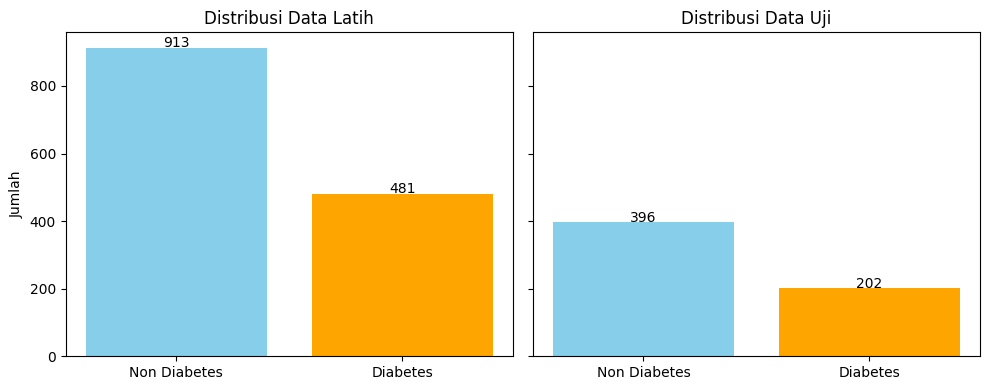

In [49]:
# distribusi kelas pada data latih dan data uji
train_y_counts = y_train.value_counts()
test_y_counts = y_test.value_counts()
test_counts  = y_test.value_counts().reindex([0, 1], fill_value=0)

labels = ["Non Diabetes", "Diabetes"]
x = [0, 1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].bar(x, train_y_counts.values, color=["skyblue", "orange"])
axes[0].set_title("Distribusi Data Latih")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Jumlah")

axes[1].bar(x, test_counts.values, color=["skyblue", "orange"])
axes[1].set_title("Distribusi Data Uji")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)

# angka di atas bar (opsional tapi masih sederhana)
for ax, counts in zip(axes, [train_y_counts, test_counts]):
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(int(v)), ha="center")

plt.tight_layout()
plt.show()

In [50]:
# balancing dengan SMOTE
jumlah_per_kelas = y_train.value_counts()
jumlah_kelas_mayoritas = jumlah_per_kelas.max()
jumlah_kelas_minoritas = jumlah_per_kelas.min()
IR = jumlah_kelas_mayoritas / jumlah_kelas_minoritas
print(f"Imbalance Ratio: {IR}")

if IR > 1.5:
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
else:
    print("Data sudah cukup seimbang")

Imbalance Ratio: 1.8981288981288982


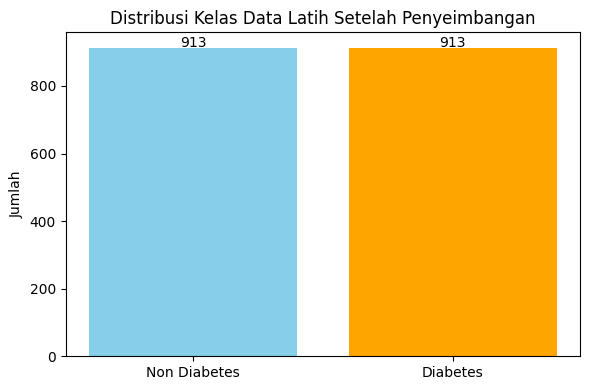

In [51]:
counts_smote =y_train_smote.value_counts()

plt.figure(figsize=(6, 4))
plt.bar([0, 1], counts_smote.values, color=["skyblue", "orange"])
plt.xticks([0, 1], ["Non Diabetes", "Diabetes"])
plt.ylabel("Jumlah")
plt.title("Distribusi Kelas Data Latih Setelah Penyeimbangan")

for i, v in enumerate(counts_smote.values):
    plt.text(i, v + 1, str(int(v)), ha="center")

plt.tight_layout()
plt.show()

In [ ]:
# Cross-validation dengan KFold
n_splits = 5
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)

for split, (train_index, validasi_index) in enumerate(kfold.split(X_train_smote, y_train_smote), 1):
    print(f"split {split}:\n")
    print(f"Jumlah data train: {len(train_index)}")
    print(f"Jumlah data validation: {len(validasi_index)}\n")
    print(f"Train index: {', '.join(map(str, train_index))}")
    print(f"Validation index:  {', '.join(map(str, validasi_index))}\n")

split 1:

Jumlah data train: 1460
Jumlah data validation: 366

Train index: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 45, 46, 47, 48, 50, 52, 53, 54, 55, 56, 57, 58, 60, 61, 62, 63, 64, 66, 68, 72, 74, 75, 77, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 100, 101, 102, 103, 104, 105, 106, 107, 108, 110, 112, 113, 114, 116, 117, 118, 119, 120, 121, 122, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 136, 137, 138, 139, 140, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 163, 164, 165, 166, 167, 169, 170, 171, 172, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 186, 187, 189, 190, 191, 192, 193, 194, 195, 197, 198, 199, 200, 201, 202, 204, 205, 206, 207, 208, 209, 211, 213, 214, 215, 216, 217, 218, 219, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 234, 235, 236, 238, 241, 24

In [53]:
# membuat model KNN dengan GridSearchCV
param_grid_knn = {
    "n_neighbors": [5, 7, 9, 11, 13, 15, 17, 19],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
}
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_knn.fit(X_train_smote, y_train_smote)
print(f"KNN Best Score: {grid_knn.best_score_:.4f}")
print(f"KNN Best Params: {grid_knn.best_params_}")
results_knn = pd.DataFrame(grid_knn.cv_results_)
best_idx = grid_knn.best_index_
best_idx = grid_knn.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_knn.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_knn.best_score_:.4f}")
knn_final = grid_knn.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits
KNN Best Score: 0.9480
KNN Best Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Fold 1: 0.9426
Fold 2: 0.9342
Fold 3: 0.9616
Fold 4: 0.9370
Fold 5: 0.9644
Mean: 0.9480


In [54]:
print(f"Metrik Jarak: {knn_final.effective_metric_}")
print(f"Jumlah Sampel Latihan: {knn_final.n_samples_fit_}")

Metrik Jarak: manhattan
Jumlah Sampel Latihan: 1826


In [95]:
out_dir = Path("for_deployment")
joblib.dump(knn_final, out_dir / "knn_model.joblib")
knn_info = {
    "model": "KNN",
    "cv": {
        "n_folds": 5,
        "n_candidates": 48,
        "total_fits": 240,
    },
    "best_score": 0.9480,
    "best_params": {"metric": "manhattan", "n_neighbors": 9, "weights": "distance"},
    "fold_scores": [0.9426, 0.9342, 0.9616, 0.9370, 0.9644],
    "mean": 0.9480,
}
with open(out_dir / "knn_info.json", "w", encoding="utf-8") as f:
    json.dump(knn_info, f, indent=2, ensure_ascii=False)

In [55]:
# membuat model Logistic Regression dengan GridSearchCV
param_grid_lr = {
    "C": np.logspace(-4, 4, 20),
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l1", "l2"],
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_lr.fit(X_train_smote, y_train_smote)

print(f"LR Best Score: {grid_lr.best_score_:.4f}")
print(f"LR Best Params: {grid_lr.best_params_}")

results_lr = pd.DataFrame(grid_lr.cv_results_)
best_idx = grid_lr.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_lr.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_lr.best_score_:.4f}")

lr_final = grid_lr.best_estimator_

Fitting 5 folds for each of 80 candidates, totalling 400 fits
LR Best Score: 0.7574
LR Best Params: {'C': np.float64(0.03359818286283781), 'penalty': 'l2', 'solver': 'liblinear'}
Fold 1: 0.7104
Fold 2: 0.7671
Fold 3: 0.7370
Fold 4: 0.8329
Fold 5: 0.7397
Mean: 0.7574


In [56]:
print(f"Koefisien (Bobot): \n{lr_final.coef_}")
print(f"Intercept (Bias): {lr_final.intercept_}")
print(f"Jumlah Iterasi: {lr_final.n_iter_}")

Koefisien (Bobot): 
[[ 0.57947611  1.40163103 -0.0347297   0.25106864  0.27961099  0.55780767
   0.22048715  0.48571201]]
Intercept (Bias): [-1.17551152]
Jumlah Iterasi: [3]


In [96]:
out_dir = Path("for_deployment")
# 1) simpan modelnya (wajib joblib/pickle)
joblib.dump(lr_final, out_dir / "lr_model.joblib")

# 2) simpan info hasilnya (boleh JSON)
lr_info = {
    "model": "LogisticRegression",
    "cv": {
        "n_folds": 5,
        "n_candidates": 80,
        "total_fits": 400,
    },
    "best_score": 0.7574,
    "best_params": {
        "C": 0.03359818286283781,   # pastikan float biasa (bukan np.float64) biar aman di JSON
        "penalty": "l2",
        "solver": "liblinear",
    },
    "fold_scores": [0.7104, 0.7671, 0.7370, 0.8329, 0.7397],
    "mean": 0.7574,

    # tambahan yang kamu minta
    "coef": [
        [0.57947611, 1.40163103, -0.0347297, 0.25106864, 0.27961099, 0.55780767, 0.22048715, 0.48571201]
    ],
    "intercept": [-1.17551152],
    "n_iter": [3],
}

with open(out_dir / "lr_info.json", "w", encoding="utf-8") as f:
    json.dump(lr_info, f, indent=2, ensure_ascii=False)

In [57]:
# membuat model SVM dengan GridSearchCV
param_grid_svm = {
    "C": [0.1, 1, 10, 100, 1000],
    "gamma": ["scale", "auto"],
    "kernel": ["rbf", "linear"],
}

grid_svm = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid_svm,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_svm.fit(X_train_smote, y_train_smote)

print(f"SVM Best Score: {grid_svm.best_score_:.4f}")
print(f"SVM Best Params: {grid_svm.best_params_}")

results_svm = pd.DataFrame(grid_svm.cv_results_)
best_idx = grid_svm.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_svm.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_svm.best_score_:.4f}")

svm_final = grid_svm.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM Best Score: 0.9190
SVM Best Params: {'C': 1000, 'gamma': 'scale', 'kernel': 'rbf'}
Fold 1: 0.9044
Fold 2: 0.9397
Fold 3: 0.9068
Fold 4: 0.9151
Fold 5: 0.9288
Mean: 0.9190


In [58]:
print(f"Indeks Support Vectors: {svm_final.support_}")
print(f"Jumlah Support Vectors per kelas: {svm_final.n_support_}")
# print(f"Bobot Fitur (coef_): \n{svm_final.coef_}")
print(f"Konstanta Bias (intercept_): {svm_final.intercept_}")

Indeks Support Vectors: [   7   16   25   41   46   56   61   86   88   89   92   93   96   98
  110  114  120  123  125  127  132  133  149  150  163  165  174  178
  182  184  185  198  199  211  221  222  238  257  263  269  273  274
  279  281  287  290  300  311  312  313  324  325  332  334  340  345
  348  350  352  364  367  370  376  378  380  392  398  399  401  407
  410  412  431  436  438  440  447  448  451  452  455  463  468  472
  476  479  490  504  506  519  556  564  568  571  575  577  579  580
  587  595  597  607  617  632  634  635  644  650  669  672  675  676
  680  682  688  691  692  695  710  715  718  722  723  729  732  735
  740  741  748  756  760  767  770  774  775  778  795  804  811  812
  824  825  831  832  833  836  841  846  854  857  868  878  886  894
  897  908  911  920  922  925  927  937  940  941  950  955  957  996
 1001 1002 1004 1009 1023 1025 1028 1041 1044 1062 1064 1066 1067 1068
 1085 1092 1108 1113 1114 1127 1139 1158 1163 1167 11

In [97]:
out_dir = Path("for_deployment")

# simpan model
joblib.dump(svm_final, out_dir / "svm_model.joblib")

# simpan info (hardcode)
svm_info = {
    "model": "SVM",
    "cv": {
        "n_folds": 5,
        "n_candidates": 20,
        "total_fits": 100,
    },
    "best_score": 0.9190,
    "best_params": {
        "C": 1000,
        "gamma": "scale",
        "kernel": "rbf",
    },
    "fold_scores": [0.9044, 0.9397, 0.9068, 0.9151, 0.9288],
    "mean": 0.9190,
}

with open(out_dir / "svm_info.json", "w", encoding="utf-8") as f:
    json.dump(svm_info, f, indent=2, ensure_ascii=False)


In [59]:
# membuat model ann dengan GridSearchCV
param_grid_ann = {
    "max_iter": [100, 500, 1000],
    "hidden_layer_sizes": [(100,), (50, 50), (30, 20), (20, 10)],
    "activation": ["relu", "tanh", "logistic"],
    "alpha": [0.0001, 0.001, 0.01, 0.1],
}

grid_ann = GridSearchCV(
    MLPClassifier(random_state=42),
    param_grid_ann,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_ann.fit(X_train_smote, y_train_smote)

print(f"ANN Best Score: {grid_ann.best_score_:.4f}")
print(f"ANN Best Params: {grid_ann.best_params_}")

results_ann = pd.DataFrame(grid_ann.cv_results_)
best_idx = grid_ann.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_ann.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_ann.best_score_:.4f}")

ann_final = grid_ann.best_estimator_

Fitting 5 folds for each of 144 candidates, totalling 720 fits
ANN Best Score: 0.8412
ANN Best Params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (50, 50), 'max_iter': 1000}
Fold 1: 0.8005
Fold 2: 0.8685
Fold 3: 0.8521
Fold 4: 0.8575
Fold 5: 0.8274
Mean: 0.8412


In [60]:
# Hasil pelatihan ANN
print(ann_final.loss_)
print(ann_final.n_iter_)
print(ann_final.t_)
print(ann_final.n_layers_)
print(ann_final.n_outputs_)
print(ann_final.out_activation_)
print(f"\nShape Matriks Bobot (coefs_): {[c.shape for c in ann_final.coefs_]}")
print(f"Shape Vektor Bias (intercepts_): {[i.shape for i in ann_final.intercepts_]}")

0.3271765442125684
411
750486
4
1
logistic

Shape Matriks Bobot (coefs_): [(8, 50), (50, 50), (50, 1)]
Shape Vektor Bias (intercepts_): [(50,), (50,), (1,)]


In [61]:
print(f"\nShape Matriks Bobot (coefs_): {[c.shape for c in ann_final.coefs_]}")
print(f"Shape Vektor Bias (intercepts_): {[i.shape for i in ann_final.intercepts_]}")


Shape Matriks Bobot (coefs_): [(8, 50), (50, 50), (50, 1)]
Shape Vektor Bias (intercepts_): [(50,), (50,), (1,)]


In [98]:
out_dir = Path("for_deployment")

# simpan model
joblib.dump(ann_final, out_dir / "ann_model.joblib")

# simpan info (hardcode)
ann_info = {
    "model": "ANN",
    "cv": {
        "n_folds": 5,
        "n_candidates": 144,
        "total_fits": 720,
    },
    "best_score": 0.8412,
    "best_params": {
        "activation": "relu",
        "alpha": 0.0001,
        "hidden_layer_sizes": [50, 50],  # JSON tidak punya tuple, jadi pakai list
        "max_iter": 1000,
    },
    "fold_scores": [0.8005, 0.8685, 0.8521, 0.8575, 0.8274],
    "mean": 0.8412,
}

with open(out_dir / "ann_info.json", "w", encoding="utf-8") as f:
    json.dump(ann_info, f, indent=2, ensure_ascii=False)

In [62]:
# membuat fitur training meta learner dengan prediksi probabilitas
prediksi_lr = cross_val_predict(lr_final, X_train_smote, y_train_smote, cv=kfold, method="predict_proba")
prediksi_knn = cross_val_predict(knn_final, X_train_smote, y_train_smote, cv=kfold, method="predict_proba")
prediksi_svm = cross_val_predict(svm_final, X_train_smote, y_train_smote, cv=kfold, method="predict_proba")
prediksi_ann = cross_val_predict(ann_final, X_train_smote, y_train_smote, cv=kfold, method="predict_proba")

In [63]:
fitur_meta = np.column_stack([
    prediksi_lr,
    prediksi_knn,
    prediksi_svm,
    prediksi_ann,
    # y_train_smote
])
df_fitur_meta = pd.DataFrame(
    fitur_meta,
    columns=[
        "lr_prob_0", "lr_prob_1",
        "knn_prob_0", "knn_prob_1",
        "svm_prob_0", "svm_prob_1",
        "ann_prob_0", "ann_prob_1",
        # "Outcome"
    ],
)
# df_fitur_meta["Outcome"] = df_fitur_meta["Outcome"].astype(int)

In [64]:
df_fitur_meta

,lr_prob_0,lr_prob_1,knn_prob_0,knn_prob_1,svm_prob_0,svm_prob_1,ann_prob_0,ann_prob_1
0,0.441214,0.558786,1.000000,0.000000,9.935325e-01,0.006467,0.998571,0.001429
1,0.432688,0.567312,0.003918,0.996082,9.597284e-02,0.904027,0.174964,0.825036
2,0.349087,0.650913,0.000000,1.000000,5.185741e-03,0.994814,0.031690,0.968310
3,0.597913,0.402087,1.000000,0.000000,9.985597e-01,0.001440,0.997740,0.002260
4,0.487966,0.512034,0.630740,0.369260,3.304880e-01,0.669512,0.539159,0.460841
...,...,...,...,...,...,...,...,...
1821,0.361839,0.638161,0.000000,1.000000,6.767836e-06,0.999993,0.004392,0.995608
1822,0.340295,0.659705,0.000000,1.000000,8.019312e-11,1.000000,0.001131,0.998869
1823,0.359256,0.640744,0.000000,1.000000,1.669178e-01,0.833082,0.090227,0.909773
1824,0.317615,0.682385,0.000993,0.999007,8.666572e-02,0.913334,0.003325,0.996675


In [99]:
# simpan ke excel
df_fitur_meta.to_excel("fitur_meta_training.xlsx", index=False)

In [65]:
# membuat fitur testing meta learner dengan prediksi probabilitas
prediksi_uji_lr = lr_final.predict_proba(X_test)
prediksi_uji_knn = knn_final.predict_proba(X_test)
prediksi_uji_svm = svm_final.predict_proba(X_test)
prediksi_uji_ann = ann_final.predict_proba(X_test)
fitur_meta_uji = np.column_stack([prediksi_uji_lr, prediksi_uji_knn, prediksi_uji_svm, prediksi_uji_ann])
df_fitur_meta_uji = pd.DataFrame(
    fitur_meta_uji,
    columns=df_fitur_meta.columns,
)

In [66]:
df_fitur_meta_uji

,lr_prob_0,lr_prob_1,knn_prob_0,knn_prob_1,svm_prob_0,svm_prob_1,ann_prob_0,ann_prob_1
0,0.418900,0.581100,0.000000,1.000000,1.854071e-01,0.814593,0.122666,0.877334
1,0.362846,0.637154,0.000000,1.000000,1.101824e-01,0.889818,0.072452,0.927548
2,0.505594,0.494406,0.000000,1.000000,8.393369e-02,0.916066,0.104458,0.895542
3,0.599785,0.400215,1.000000,0.000000,9.985153e-01,0.001485,0.948284,0.051716
4,0.403445,0.596555,0.989511,0.010489,8.351166e-01,0.164883,0.070595,0.929405
...,...,...,...,...,...,...,...,...
593,0.435063,0.564937,0.991013,0.008987,9.987507e-01,0.001249,0.882977,0.117023
594,0.284451,0.715549,0.000000,1.000000,1.321167e-07,1.000000,0.026433,0.973567
595,0.393085,0.606915,0.073359,0.926641,1.299420e-08,1.000000,0.080546,0.919454
596,0.397312,0.602688,0.000000,1.000000,1.294740e-01,0.870526,0.065117,0.934883


In [100]:
# simpan fitur meta testing
df_fitur_meta_uji.to_excel("fitur_meta_testing.xlsx", index=False)

In [67]:
X_meta_latih = df_fitur_meta
y_meta_latih = y_train_smote

X_meta_uji = df_fitur_meta_uji
y_meta_uji = y_test

In [68]:
# membuat model KNN Meta dengan GridSearchCV
grid_knn_meta = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_knn_meta.fit(X_meta_latih, y_meta_latih)

print(f"KNN Meta Best Score: {grid_knn_meta.best_score_:.4f}")
print(f"KNN Meta Best Params: {grid_knn_meta.best_params_}")

results_knn_meta = pd.DataFrame(grid_knn_meta.cv_results_)
best_idx = grid_knn_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_knn_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_knn_meta.best_score_:.4f}")

knn_meta_final = grid_knn_meta.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits
KNN Meta Best Score: 0.9480
KNN Meta Best Params: {'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'uniform'}
Fold 1: 0.9372
Fold 2: 0.9397
Fold 3: 0.9671
Fold 4: 0.9452
Fold 5: 0.9507
Mean: 0.9480


In [69]:
print(f"Metrik Jarak: {knn_meta_final.effective_metric_}")
print(f"Jumlah Sampel Latihan: {knn_meta_final.n_samples_fit_}")

Metrik Jarak: manhattan
Jumlah Sampel Latihan: 1826


In [105]:
joblib.dump(knn_meta_final,    out_dir / "knn_meta_model.joblib")
knn_meta_info = {
    "model": "KNN_META",
    "cv": {"n_folds": 5, "n_candidates": 48, "total_fits": 240},
    "best_score": 0.9480,
    "best_params": {"metric": "manhattan", "n_neighbors": 13, "weights": "uniform"},
    "fold_scores": [0.9372, 0.9397, 0.9671, 0.9452, 0.9507],
    "mean": 0.9480,
}
with open(out_dir / "knn_meta_info.json", "w", encoding="utf-8") as f:
    json.dump(knn_meta_info, f, indent=2, ensure_ascii=False)


In [70]:
# membuat model Logistic Regression Meta dengan GridSearchCV
grid_logreg_meta = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_logreg_meta.fit(X_meta_latih, y_meta_latih)

print(f"LogReg Meta Best Score: {grid_logreg_meta.best_score_:.4f}")
print(f"LogReg Meta Best Params: {grid_logreg_meta.best_params_}")

results_logreg_meta = pd.DataFrame(grid_logreg_meta.cv_results_)
best_idx = grid_logreg_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_logreg_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_logreg_meta.best_score_:.4f}")

logreg_meta_final = grid_logreg_meta.best_estimator_


Fitting 5 folds for each of 80 candidates, totalling 400 fits
LogReg Meta Best Score: 0.9485
LogReg Meta Best Params: {'C': np.float64(0.23357214690901212), 'penalty': 'l1', 'solver': 'liblinear'}
Fold 1: 0.9426
Fold 2: 0.9397
Fold 3: 0.9589
Fold 4: 0.9397
Fold 5: 0.9616
Mean: 0.9485


In [71]:
print(f"Koefisien (Bobot): \n{logreg_meta_final.coef_}")
print(f"Intercept (Bias): {logreg_meta_final.intercept_}")
print(f"Jumlah Iterasi: {logreg_meta_final.n_iter_}")

Koefisien (Bobot): 
[[ 0.          0.         -3.80377742  3.29858819 -0.6489145   0.36690496
   0.          0.        ]]
Intercept (Bias): [0.]
Jumlah Iterasi: [12]


In [104]:
joblib.dump(logreg_meta_final, out_dir / "logreg_meta_model.joblib")
logreg_meta_info = {
    "model": "LogReg_META",
    "cv": {"n_folds": 5, "n_candidates": 80, "total_fits": 400},
    "best_score": 0.9485,
    "best_params": {
        "C": 0.23357214690901212,  # float biasa biar aman di JSON
        "penalty": "l1",
        "solver": "liblinear",
    },
    "fold_scores": [0.9426, 0.9397, 0.9589, 0.9397, 0.9616],
    "mean": 0.9485,
}
with open(out_dir / "logreg_meta_info.json", "w", encoding="utf-8") as f:
    json.dump(logreg_meta_info, f, indent=2, ensure_ascii=False)

In [72]:
# membuat model Support Vector Machine Meta dengan GridSearchCV
grid_svm_meta = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid_svm,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_svm_meta.fit(X_meta_latih, y_meta_latih)

print(f"SVM Meta Best Score: {grid_svm_meta.best_score_:.4f}")
print(f"SVM Meta Best Params: {grid_svm_meta.best_params_}")

results_svm_meta = pd.DataFrame(grid_svm_meta.cv_results_)
best_idx = grid_svm_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_svm_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_svm_meta.best_score_:.4f}")

svm_meta_final = grid_svm_meta.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM Meta Best Score: 0.9485
SVM Meta Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Fold 1: 0.9454
Fold 2: 0.9370
Fold 3: 0.9589
Fold 4: 0.9452
Fold 5: 0.9562
Mean: 0.9485


In [73]:
print(f"Indeks Support Vectors: {svm_meta_final.support_}")
print(f"Jumlah Support Vectors per kelas: {svm_meta_final.n_support_}")
# print(f"Bobot Fitur (coef_): \n{svm_meta_final.coef_}")
print(f"Konstanta Bias (intercept_): {svm_meta_final.intercept_}")

Indeks Support Vectors: [   6   39   43   46   56   61   86   89   92   98  123  132  134  156
  159  184  198  207  224  238  239  248  276  287  290  300  309  313
  325  334  340  349  370  378  380  382  389  392  407  413  422  429
  438  440  455  472  476  486  498  503  542  552  560  568  589  597
  617  634  635  644  647  650  672  675  682  708  712  723  724  729
  730  737  740  748  761  767  776  778  787  812  816  823  824  832
  833  860  868  878  884  886  897  911  920  922  941  996 1001 1004
 1013 1023 1028 1064 1073 1082 1112 1113 1114 1131 1137 1163 1165 1167
 1171 1173 1182 1184 1191 1192 1198 1201 1212 1215 1222 1226 1229 1239
 1244 1248 1258 1262 1282 1291 1292 1322 1325 1330 1338 1361 1382 1385
    4   19   55   69   80   99  131  142  144  155  173  181  191  201
  232  235  240  244  250  251  267  284  299  317  383  388  391  406
  408  415  416  427  439  441  474  480  516  518  523  533  545  576
  583  584  592  615  651  667  683  693  736  744  7

In [102]:
joblib.dump(svm_meta_final,out_dir / "svm_meta_model.joblib")
svm_meta_info = {
    "model": "SVM_META",
    "cv": {"n_folds": 5, "n_candidates": 20, "total_fits": 100},
    "best_score": 0.9485,
    "best_params": {"C": 0.1, "gamma": "scale", "kernel": "rbf"},
    "fold_scores": [0.9454, 0.9370, 0.9589, 0.9452, 0.9562],
    "mean": 0.9485,
}
with open(out_dir / "svm_meta_info.json", "w", encoding="utf-8") as f:
    json.dump(svm_meta_info, f, indent=2, ensure_ascii=False)


In [74]:
# membuat model ANN Meta dengan GridSearchCV
grid_ann_meta = GridSearchCV(
    MLPClassifier(random_state=42),
    param_grid_ann,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_ann_meta.fit(X_meta_latih, y_meta_latih)

print(f"ANN Meta Best Score: {grid_ann_meta.best_score_:.4f}")
print(f"ANN Meta Best Params: {grid_ann_meta.best_params_}")

results_ann_meta = pd.DataFrame(grid_ann_meta.cv_results_)
best_idx = grid_ann_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_ann_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_ann_meta.best_score_:.4f}")

ann_meta_final = grid_ann_meta.best_estimator_


Fitting 5 folds for each of 144 candidates, totalling 720 fits
ANN Meta Best Score: 0.9491
ANN Meta Best Params: {'activation': 'logistic', 'alpha': 0.0001, 'hidden_layer_sizes': (50, 50), 'max_iter': 100}
Fold 1: 0.9454
Fold 2: 0.9370
Fold 3: 0.9616
Fold 4: 0.9452
Fold 5: 0.9562
Mean: 0.9491


In [75]:
# Hasil pelatihan ANN
print(ann_meta_final.loss_)
print(ann_meta_final.n_iter_)
print(ann_meta_final.t_)
print(ann_meta_final.n_layers_)
print(ann_meta_final.n_outputs_)
print(ann_meta_final.out_activation_)
print(f"\nShape Matriks Bobot (coefs_): {[c.shape for c in ann_meta_final.coefs_]}")
print(f"Shape Vektor Bias (intercepts_): {[i.shape for i in ann_meta_final.intercepts_]}")

0.15826000282850397
100
182600
4
1
logistic

Shape Matriks Bobot (coefs_): [(8, 50), (50, 50), (50, 1)]
Shape Vektor Bias (intercepts_): [(50,), (50,), (1,)]


In [101]:
joblib.dump(ann_meta_final,    out_dir / "ann_meta_model.joblib")
ann_meta_info = {
    "model": "ANN_META",
    "cv": {"n_folds": 5, "n_candidates": 144, "total_fits": 720},
    "best_score": 0.9491,
    "best_params": {
        "activation": "logistic",
        "alpha": 0.0001,
        "hidden_layer_sizes": [50, 50],  # JSON tidak punya tuple → pakai list
        "max_iter": 100,
    },
    "fold_scores": [0.9454, 0.9370, 0.9616, 0.9452, 0.9562],
    "mean": 0.9491,
}
with open(out_dir / "ann_meta_info.json", "w", encoding="utf-8") as f:
    json.dump(ann_meta_info, f, indent=2, ensure_ascii=False)

In [76]:
# contoh prediksi dengan model ANN Meta terbaik
best_meta_ann = grid_ann_meta.best_estimator_
best_meta_ann.predict(X_meta_uji)

array([1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1,

In [77]:
# pengujian model meta learner terbaik dengan data uji
pred_model_dasar = {
    "LogReg": lr_final.predict(X_test),
    "KNN": knn_final.predict(X_test),
    "SVM": svm_final.predict(X_test),
    "ANN": ann_final.predict(X_test),
}

stacking_predictions = {
    "Stacking_KNN": knn_meta_final.predict(X_meta_uji),
    "Stacking_SVM": svm_meta_final.predict(X_meta_uji),
    "Stacking_ANN": ann_meta_final.predict(X_meta_uji),
    "Stacking_LogReg": logreg_meta_final.predict(X_meta_uji),
}


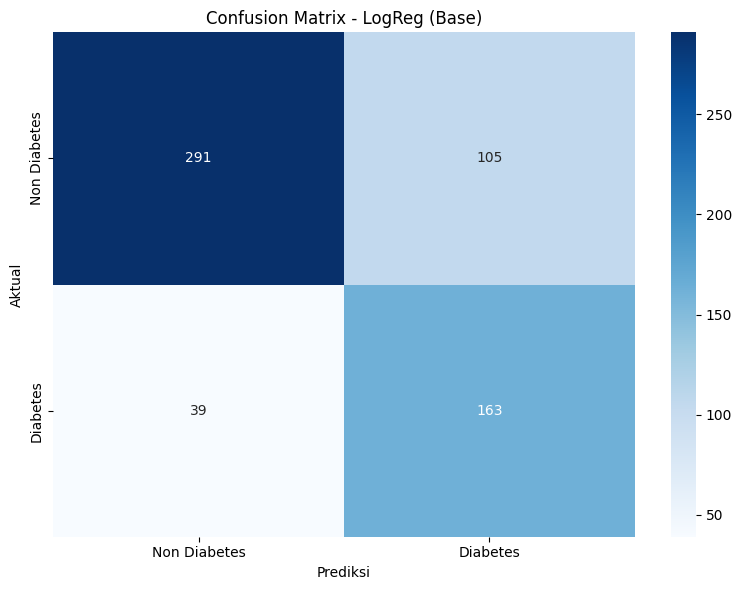

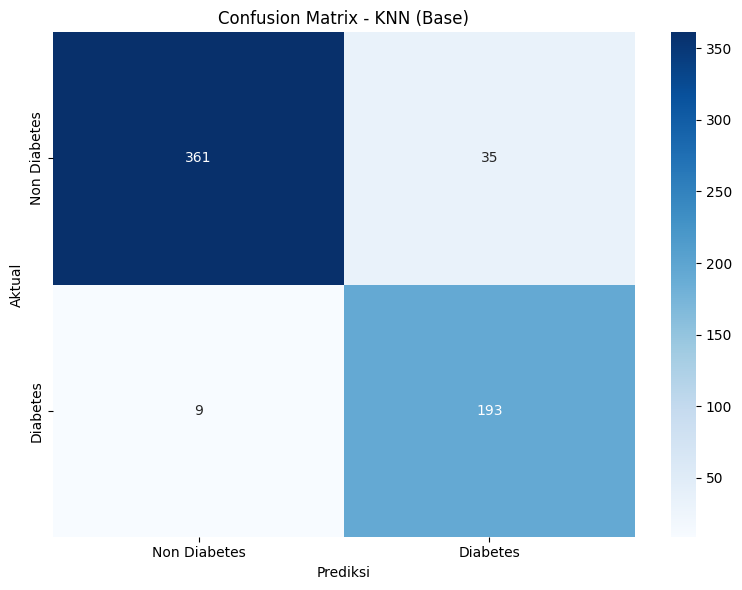

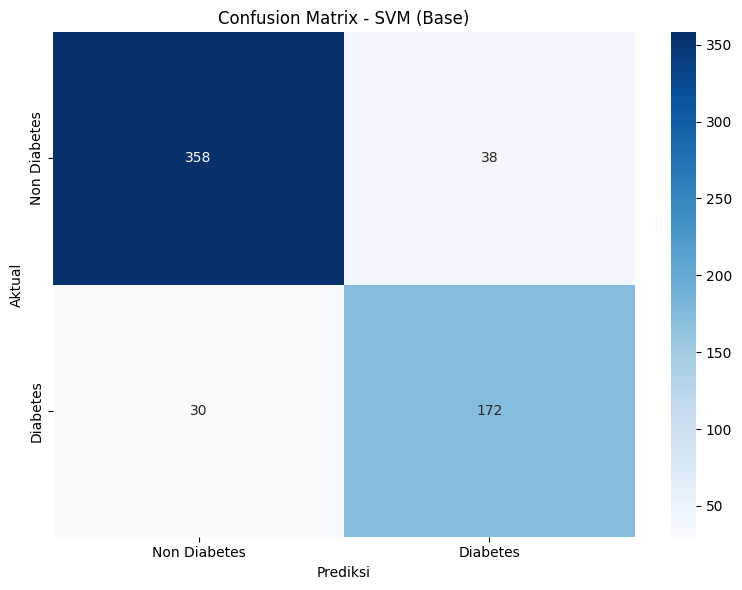

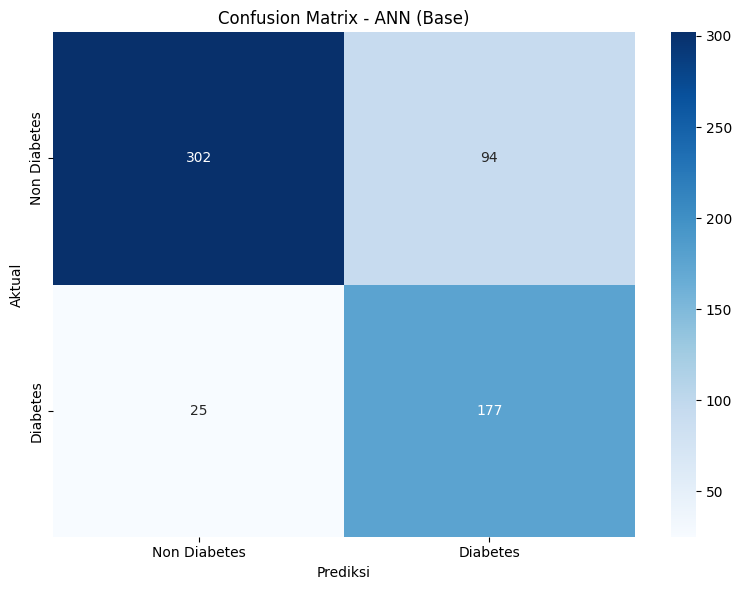

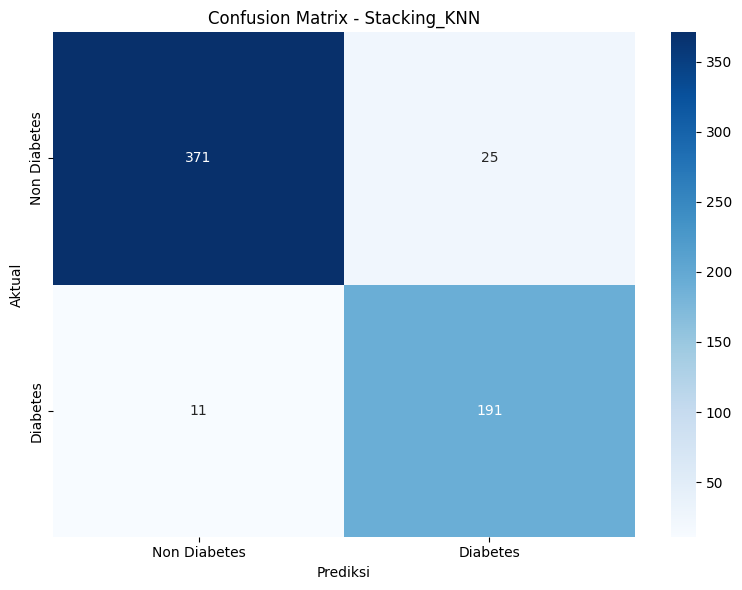

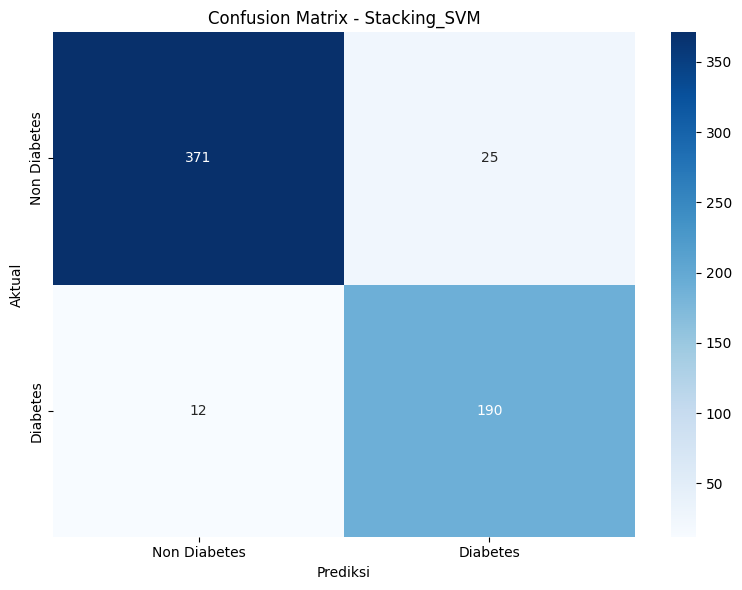

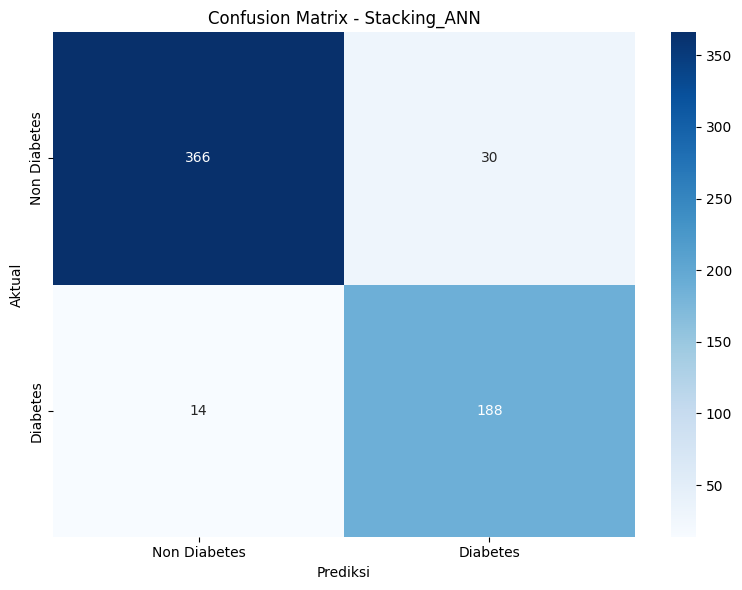

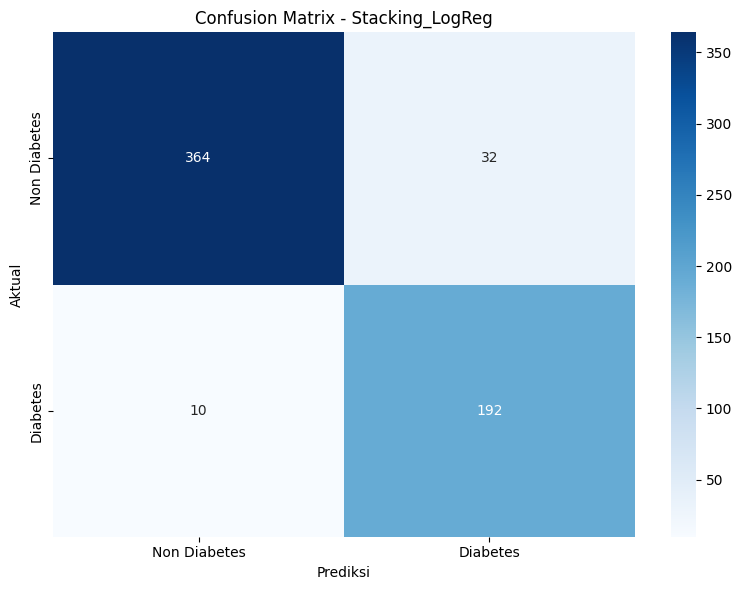

In [78]:
# evaluasi model
# ================================
# 4.2.14 Confusion Matrix
# ================================
def plot_confusion_matrix(y_asli, y_prediksi, nama_model):
    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(y_asli, y_prediksi)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Non Diabetes", "Diabetes"],
        yticklabels=["Non Diabetes", "Diabetes"],
    )
    ax.set_title(f"Confusion Matrix - {nama_model}")
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Aktual")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

for nama_model, prediksi in pred_model_dasar.items():
    plot_confusion_matrix(y_test, prediksi, f"{nama_model} (Base)")

for nama_model, prediksi in stacking_predictions.items():
    plot_confusion_matrix(y_test, prediksi, nama_model)

In [79]:
def hitung_metrik(y_asli, y_prediksi, nama_model):
    akurasi = accuracy_score(y_asli, y_prediksi)
    presisi = precision_score(y_asli, y_prediksi)
    recall = recall_score(y_asli, y_prediksi)
    f1 = f1_score(y_asli, y_prediksi)
    return {"Model": nama_model, "Akurasi": akurasi, "Presisi": presisi, "Recall": recall, "Skor-F1": f1}

hasil_perbandingan = []
for nama_model, prediksi in pred_model_dasar.items():
    hasil_perbandingan.append(hitung_metrik(y_test, prediksi, nama_model))
for nama_model, prediksi in stacking_predictions.items():
    hasil_perbandingan.append(hitung_metrik(y_test, prediksi, nama_model))

df_perbandingan = pd.DataFrame(hasil_perbandingan)
print(df_perbandingan)

             Model   Akurasi   Presisi    Recall   Skor-F1
0           LogReg  0.759197  0.608209  0.806931  0.693617
1              KNN  0.926421  0.846491  0.955446  0.897674
2              SVM  0.886288  0.819048  0.851485  0.834951
3              ANN  0.801003  0.653137  0.876238  0.748414
4     Stacking_KNN  0.939799  0.884259  0.945545  0.913876
5     Stacking_SVM  0.938127  0.883721  0.940594  0.911271
6     Stacking_ANN  0.926421  0.862385  0.930693  0.895238
7  Stacking_LogReg  0.929766  0.857143  0.950495  0.901408


In [80]:
import pandas as pd

def cv_results_to_export(nama_model, results_df):
    df = results_df[["params", "mean_test_score", "rank_test_score"]].copy()
    df = df.dropna(subset=["mean_test_score"])

    df.rename(columns={
        "params": "Kombinasi Parameter",
        "mean_test_score": "Rata Rata",
        "rank_test_score": "Peringkat",
    }, inplace=True)

    df.insert(0, "Nama Model", nama_model)
    df["Kombinasi Parameter"] = df["Kombinasi Parameter"].astype(str)
    return df

# =========================
# BASE (sheet 1)
# =========================
df_base = pd.concat([
    cv_results_to_export("KNN", results_knn),
    cv_results_to_export("LogReg", results_lr),
    cv_results_to_export("SVM", results_svm),
    cv_results_to_export("ANN", results_ann),
], ignore_index=True)

df_base = df_base.sort_values(["Nama Model", "Peringkat"], ascending=[True, True]).reset_index(drop=True)
df_base.insert(0, "No", range(1, len(df_base) + 1))

# =========================
# META (sheet 2)
# =========================
df_meta = pd.concat([
    cv_results_to_export("KNN", results_knn_meta),
    cv_results_to_export("LogReg", results_logreg_meta),
    cv_results_to_export("SVM", results_svm_meta),
    cv_results_to_export("ANN", results_ann_meta),
], ignore_index=True)

df_meta = df_meta.sort_values(["Nama Model", "Peringkat"], ascending=[True, True]).reset_index(drop=True)
df_meta.insert(0, "No", range(1, len(df_meta) + 1))

# =========================
# EXPORT (2 sheet)
# =========================
output_excel = "rekap_kombinasi_parameter_base_dan_meta.xlsx"
with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    df_base.to_excel(writer, index=False, sheet_name="Base")
    df_meta.to_excel(writer, index=False, sheet_name="Meta")

print("Berhasil membuat:", output_excel)
print("Total baris Base:", len(df_base))
print("Total baris Meta:", len(df_meta))

Berhasil membuat: rekap_kombinasi_parameter_base_dan_meta.xlsx
Total baris Base: 272
Total baris Meta: 272
